In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.figure import Figure
from matplotlib.axes import Axes

In [4]:
lf = pl.scan_csv('df.csv')
print(lf.head().collect())

shape: (5, 7)
┌──────────┬────────┬──────────────┬────────────────┬─────────────┬──────────┬────────┐
│ wafer_id ┆ lot_id ┆ defect_count ┆ defect_density ┆ temperature ┆ pressure ┆ passed │
│ ---      ┆ ---    ┆ ---          ┆ ---            ┆ ---         ┆ ---      ┆ ---    │
│ str      ┆ str    ┆ i64          ┆ f64            ┆ f64         ┆ f64      ┆ bool   │
╞══════════╪════════╪══════════════╪════════════════╪═════════════╪══════════╪════════╡
│ W001     ┆ L001   ┆ 6            ┆ 0.008571       ┆ 227.251815  ┆ 2.076848 ┆ true   │
│ W002     ┆ L001   ┆ 19           ┆ 0.027143       ┆ 227.068261  ┆ 1.994036 ┆ false  │
│ W003     ┆ L001   ┆ 14           ┆ 0.02           ┆ 218.539557  ┆ 2.192271 ┆ false  │
│ W004     ┆ L001   ┆ 10           ┆ 0.014286       ┆ 254.587058  ┆ 1.948426 ┆ false  │
│ W005     ┆ L001   ┆ 7            ┆ 0.01           ┆ 212.363943  ┆ 1.992717 ┆ true   │
└──────────┴────────┴──────────────┴────────────────┴─────────────┴──────────┴────────┘


In [7]:
print(lf.describe())

shape: (9, 8)
┌────────────┬──────────┬────────┬──────────────┬────────────────┬─────────────┬──────────┬────────┐
│ statistic  ┆ wafer_id ┆ lot_id ┆ defect_count ┆ defect_density ┆ temperature ┆ pressure ┆ passed │
│ ---        ┆ ---      ┆ ---    ┆ ---          ┆ ---            ┆ ---         ┆ ---      ┆ ---    │
│ str        ┆ str      ┆ str    ┆ f64          ┆ f64            ┆ f64         ┆ f64      ┆ f64    │
╞════════════╪══════════╪════════╪══════════════╪════════════════╪═════════════╪══════════╪════════╡
│ count      ┆ 500      ┆ 500    ┆ 500.0        ┆ 500.0          ┆ 500.0       ┆ 500.0    ┆ 500.0  │
│ null_count ┆ 0        ┆ 0      ┆ 0.0          ┆ 0.0            ┆ 0.0         ┆ 0.0      ┆ 0.0    │
│ mean       ┆ null     ┆ null   ┆ 9.176        ┆ 0.013109       ┆ 226.210345  ┆ 2.007078 ┆ 0.52   │
│ std        ┆ null     ┆ null   ┆ 6.035717     ┆ 0.008622       ┆ 27.252027   ┆ 0.31277  ┆ null   │
│ min        ┆ W001     ┆ L001   ┆ 0.0          ┆ 0.0            ┆ 135.794868

In [8]:
unique_lot = (
    lf
    .select('lot_id')
    .unique()
    .count()
    .collect()
    .item()
)

print(f'There are {unique_lot} Unique Lot available in this dataset.')

There are 10 Unique Lot available in this dataset.


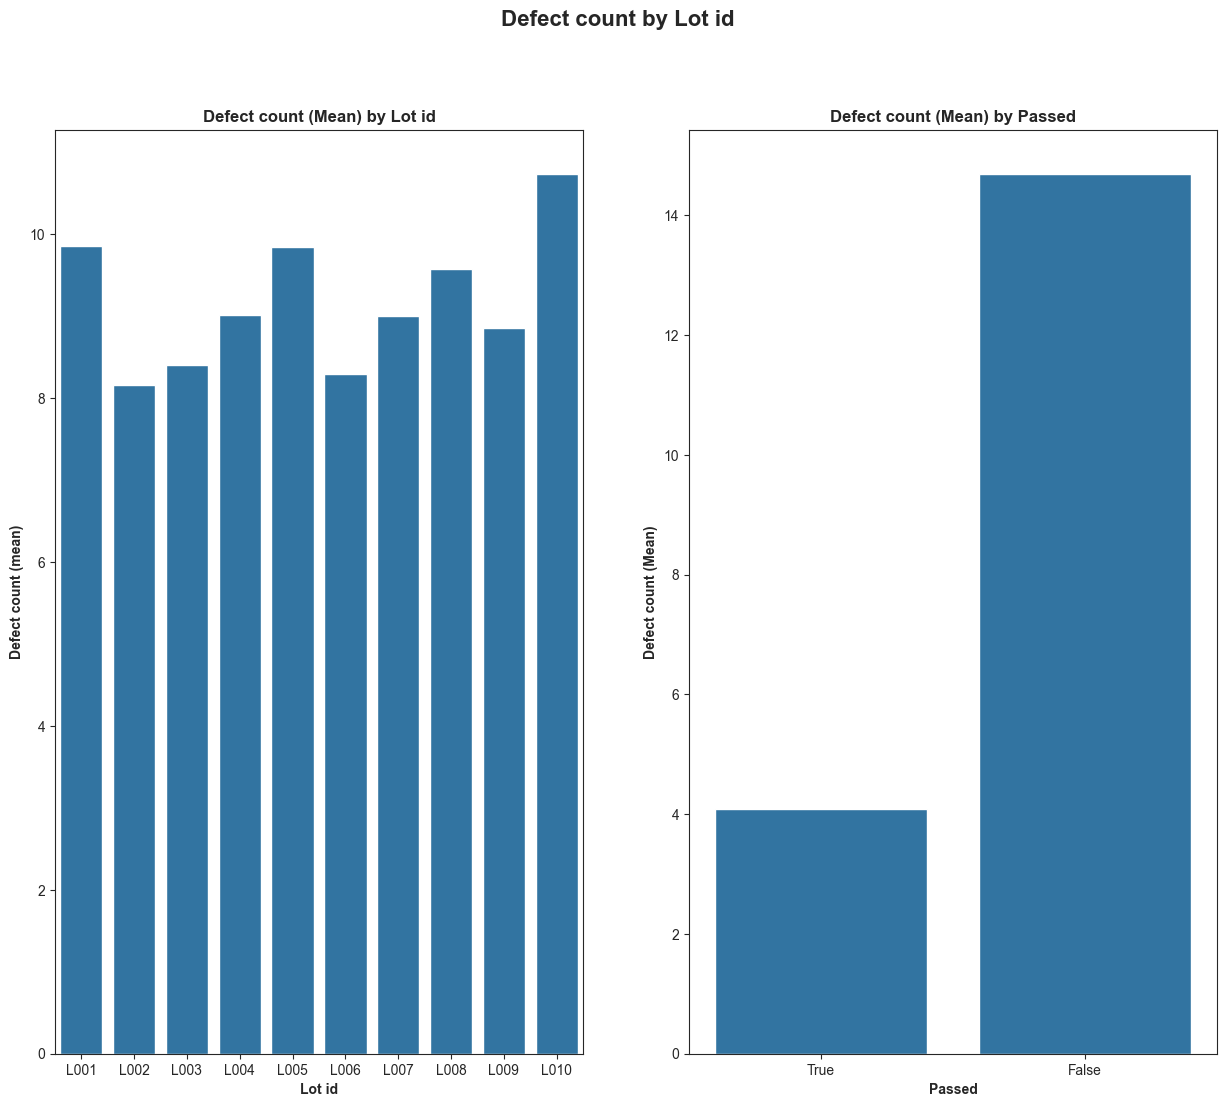

In [25]:
defect_count_by_lot_id = (
    lf
    .group_by(pl.col('lot_id'))
    .agg(
        mean = pl.col('defect_count').mean()
    )
    .collect()
)

defect_count_by_passed = (
    lf
    .group_by(pl.col('passed'))
    .agg(
        mean = pl.col('defect_count').mean()
    )
    .collect()
)

fig: Figure; ax1: Axes; ax2: Axes
sns.set_style('ticks')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 12))
fig.suptitle('Defect count by Lot id', fontsize=16, fontweight='bold')

sns.barplot(data= defect_count_by_lot_id, x='lot_id', y='mean', ax=ax1, order=['L001', 'L002', 'L003', 'L004', 'L005', 'L006', 'L007', 'L008', 'L009', 'L010'])
ax1.set_title('Defect count (Mean) by Lot id', fontweight='bold')
ax1.set_xlabel('Lot id', fontweight='bold')
ax1.set_ylabel('Defect count (mean)', fontweight='bold')

sns.barplot(data= defect_count_by_passed, x='passed', y='mean', ax=ax2, order=[True, False])
ax2.set_title('Defect count (Mean) by Passed', fontweight='bold')
ax2.set_xlabel('Passed', fontweight='bold')
ax2.set_ylabel('Defect count (Mean)', fontweight='bold')

plt.show()

Text(0, 0.5, 'Defect density (Mean)')

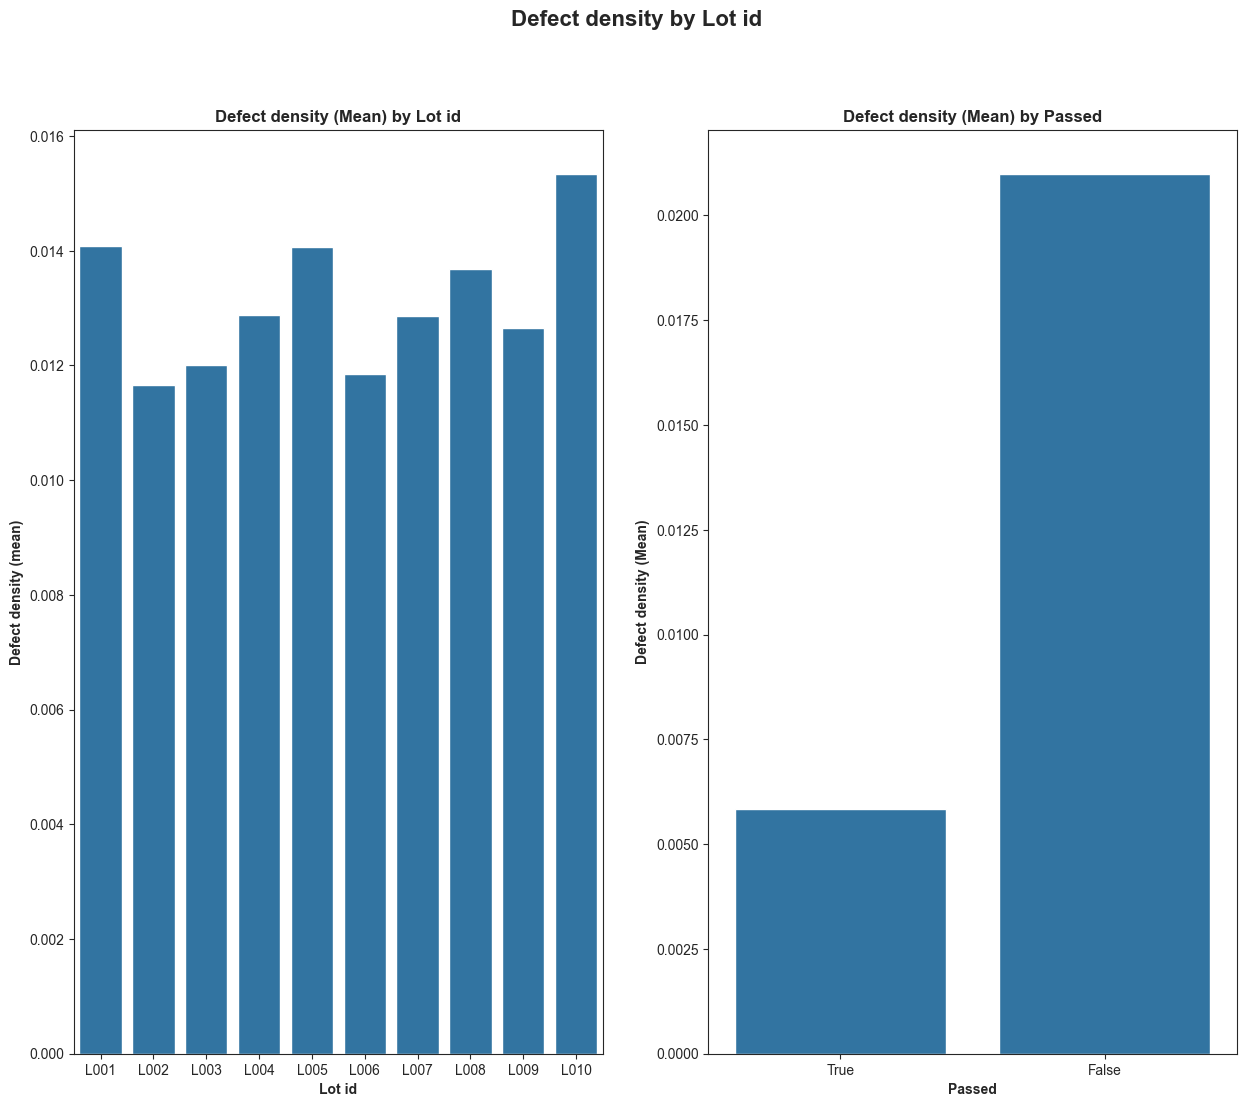

In [26]:
defect_density_by_lot_id = (
    lf
    .group_by(pl.col('lot_id'))
    .agg(
        mean = pl.col('defect_density').mean()
    )
    .collect()
)

defect_density_by_passed = (
    lf
    .group_by(pl.col('passed'))
    .agg(
        mean = pl.col('defect_density').mean()
    )
    .collect()
)

fig: Figure; ax1: Axes; ax2: Axes
sns.set_style('ticks')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 12))
fig.suptitle('Defect density by Lot id', fontsize=16, fontweight='bold')

sns.barplot(data= defect_density_by_lot_id, x='lot_id', y='mean', ax=ax1, order=['L001', 'L002', 'L003', 'L004', 'L005', 'L006', 'L007', 'L008', 'L009', 'L010'])
ax1.set_title('Defect density (Mean) by Lot id', fontweight='bold')
ax1.set_xlabel('Lot id', fontweight='bold')
ax1.set_ylabel('Defect density (mean)', fontweight='bold')

sns.barplot(data= defect_density_by_passed, x='passed', y='mean', ax=ax2, order=[True, False])
ax2.set_title('Defect density (Mean) by Passed', fontweight='bold')
ax2.set_xlabel('Passed', fontweight='bold')
ax2.set_ylabel('Defect density (Mean)', fontweight='bold')

Text(0, 0.5, 'Temperature (Mean)')

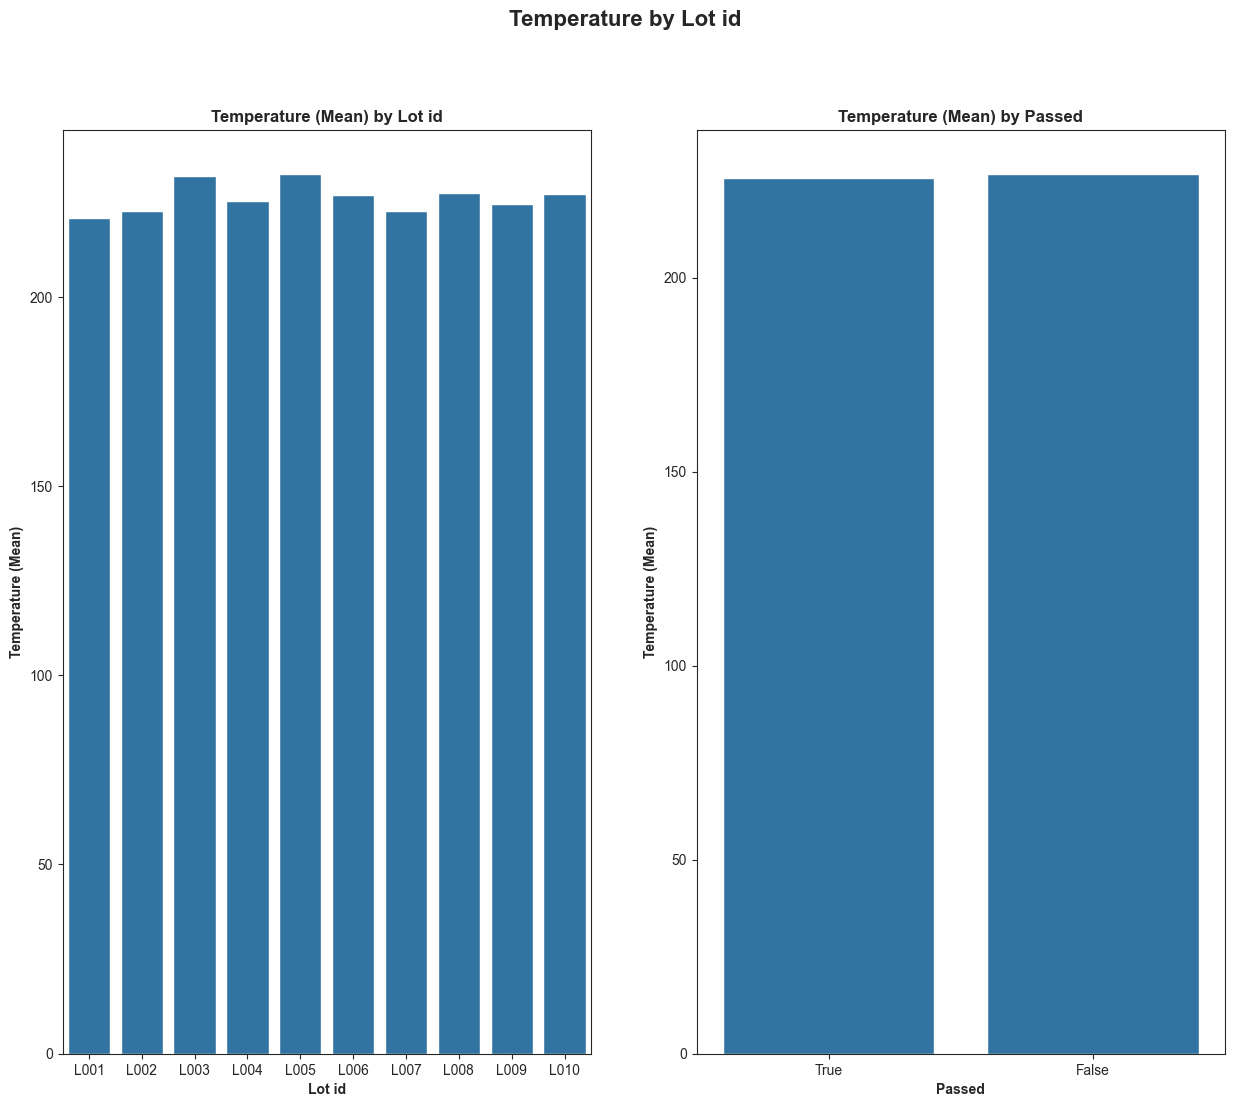

In [27]:
temperature_by_lot_id = (
    lf
    .group_by(pl.col('lot_id'))
    .agg(
        mean = pl.col('temperature').mean()
    )
    .collect()
)

temperature_by_passed = (
    lf
    .group_by(pl.col('passed'))
    .agg(
        mean = pl.col('temperature').mean()
    )
    .collect()
)

fig: Figure; ax1: Axes; ax2: Axes
sns.set_style('ticks')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 12))
fig.suptitle('Temperature by Lot id', fontsize=16, fontweight='bold')

sns.barplot(data= temperature_by_lot_id, x='lot_id', y='mean', ax=ax1, order=['L001', 'L002', 'L003', 'L004', 'L005', 'L006', 'L007', 'L008', 'L009', 'L010'])
ax1.set_title('Temperature (Mean) by Lot id', fontweight='bold')
ax1.set_xlabel('Lot id', fontweight='bold')
ax1.set_ylabel('Temperature (Mean)', fontweight='bold')

sns.barplot(data= temperature_by_passed, x='passed', y='mean', ax=ax2, order=[True, False])
ax2.set_title('Temperature (Mean) by Passed', fontweight='bold')
ax2.set_xlabel('Passed', fontweight='bold')
ax2.set_ylabel('Temperature (Mean)', fontweight='bold')

Text(0, 0.5, 'Pressure (Mean)')

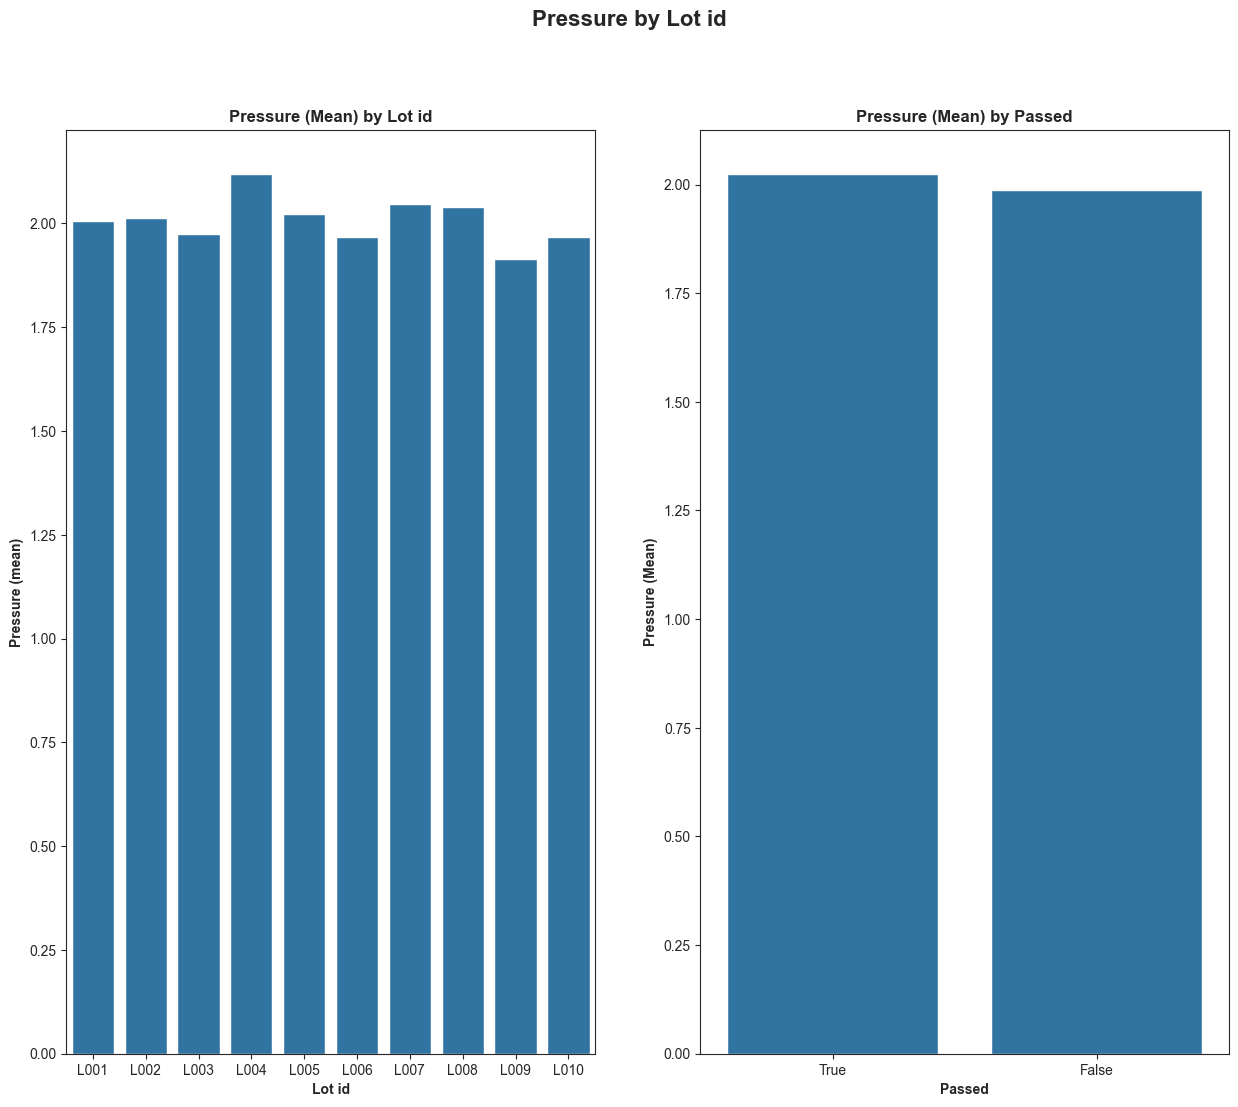

In [28]:
pressure_by_lot_id = (
    lf
    .group_by(pl.col('lot_id'))
    .agg(
        mean = pl.col('pressure').mean()
    )
    .collect()
)

pressure_by_passed = (
    lf
    .group_by(pl.col('passed'))
    .agg(
        mean = pl.col('pressure').mean()
    )
    .collect()
)

fig: Figure; ax1: Axes; ax2: Axes
sns.set_style('ticks')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 12))
fig.suptitle('Pressure by Lot id', fontsize=16, fontweight='bold')

sns.barplot(data= pressure_by_lot_id, x='lot_id', y='mean', ax=ax1, order=['L001', 'L002', 'L003', 'L004', 'L005', 'L006', 'L007', 'L008', 'L009', 'L010'])
ax1.set_title('Pressure (Mean) by Lot id', fontweight='bold')
ax1.set_xlabel('Lot id', fontweight='bold')
ax1.set_ylabel('Pressure (mean)', fontweight='bold')

sns.barplot(data= pressure_by_passed, x='passed', y='mean', ax=ax2, order=[True, False])
ax2.set_title('Pressure (Mean) by Passed', fontweight='bold')
ax2.set_xlabel('Passed', fontweight='bold')
ax2.set_ylabel('Pressure (Mean)', fontweight='bold')

In [29]:
lf = (
    lf
    .with_columns(
        pl
        .when(pl.col('passed') == False)
        .then(pl.lit(0))
        .otherwise(pl.lit(1))
        .alias('passed')
    )
)

In [35]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = lf.select(['temperature', 'pressure']).collect().to_numpy()
y = lf.select(['passed']).collect().to_series()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

my_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(max_features='sqrt', class_weight='balanced'))
])

In [36]:
param_grid = {
    'model__n_estimators' : [100, 200, 300, 500, 750, 1000],
    'model__max_depth' : [6, 10, 15, 20]
}

rf_grid = GridSearchCV(my_pipe, param_grid=param_grid, scoring='f1')
rf_grid.fit(X_train, y_train)
print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'model__max_depth': 6, 'model__n_estimators': 750}
0.5399291136083659


In [39]:
new_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(max_features='sqrt', class_weight='balanced', max_depth=6, n_estimators=750))
])

new_pipe.fit(X=X_train, y=y_train)
y_pred = new_pipe.predict(X_test)
y_proba = new_pipe.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"F1 at that threshold: {f1_scores[best_idx]:.3f}")
print(classification_report(y_test, y_pred))

Best threshold: 0.301
F1 at that threshold: 0.698
              precision    recall  f1-score   support

           0       0.50      0.44      0.47        48
           1       0.53      0.60      0.56        52

    accuracy                           0.52       100
   macro avg       0.52      0.52      0.52       100
weighted avg       0.52      0.52      0.52       100



In [40]:
class ThresholdedClassifier:
    def __init__(self, pipeline, threshold):
        self.pipeline = pipeline
        self.threshold = threshold
    
    def predict(self, X):
        proba = self.pipeline.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)
    
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

final_pipe = ThresholdedClassifier(new_pipe, 0.301)


In [41]:
import joblib

joblib.dump(final_pipe, 'finalpipe.joblib')

['finalpipe.joblib']